In [1]:
#venv_fswot
# (need cftime)

#%matplotlib inline
import numpy as np
from datetime import timedelta, datetime

In [2]:
from glob import glob
import xarray as xr
import matplotlib.pyplot as plt
from netCDF4 import num2date, date2num


import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib import colors 

import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter#
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

In [3]:
rootdir = "/Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/"

# Drifters:

In [4]:
!ls ./../../../../../../data/drifters/L1_IMEDEA/*car*

./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe006-ime_carthe001.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe007-ime_carthe002.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe008-ime_carthe003.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe009-ime_carthe004.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe010-ime_carthe005.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe011-ime_carthe006.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe012-ime_carthe007.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe013-ime_carthe008.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe014-ime_carthe009.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe015-ime_carthe010.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe016-ime_carthe011.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe017-ime_carthe012.nc
./../../../../../../data/drifters/L1_IMEDEA/drifter_

In [5]:
filedir = "./../../../../../../data/drifters/L1_IMEDEA/"

# outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
# outname = outname.split('_')[1]
ndrifters = np.arange(1, 21)
print(ndrifters)


[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [6]:
#remove carthe 4 (short traj, see: code/data_processing/drifters/processing/testing/ios_filt_drifters_CU_test02.ipynb)
# ndrifters = np.delete(ndrifters, [3, 9, 11, 12, 18]) # --> not necessary anymore (fixed in function)
ndrifters

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [7]:
import sys
sys.path.insert(0, "../../../processing/")
from ios_filt_drifters_CUTOFF import filt_ios_butter

In [8]:
outdir_root = '/Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/'

In [9]:
# filt_ios_butter(infile, drifter_type, cuttof_frequency = 1/36., outdir=None, plot_output="no", savefigdir=None):

1
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe006-ime_carthe001.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe001_inertial_osc_filt_v2.jpg


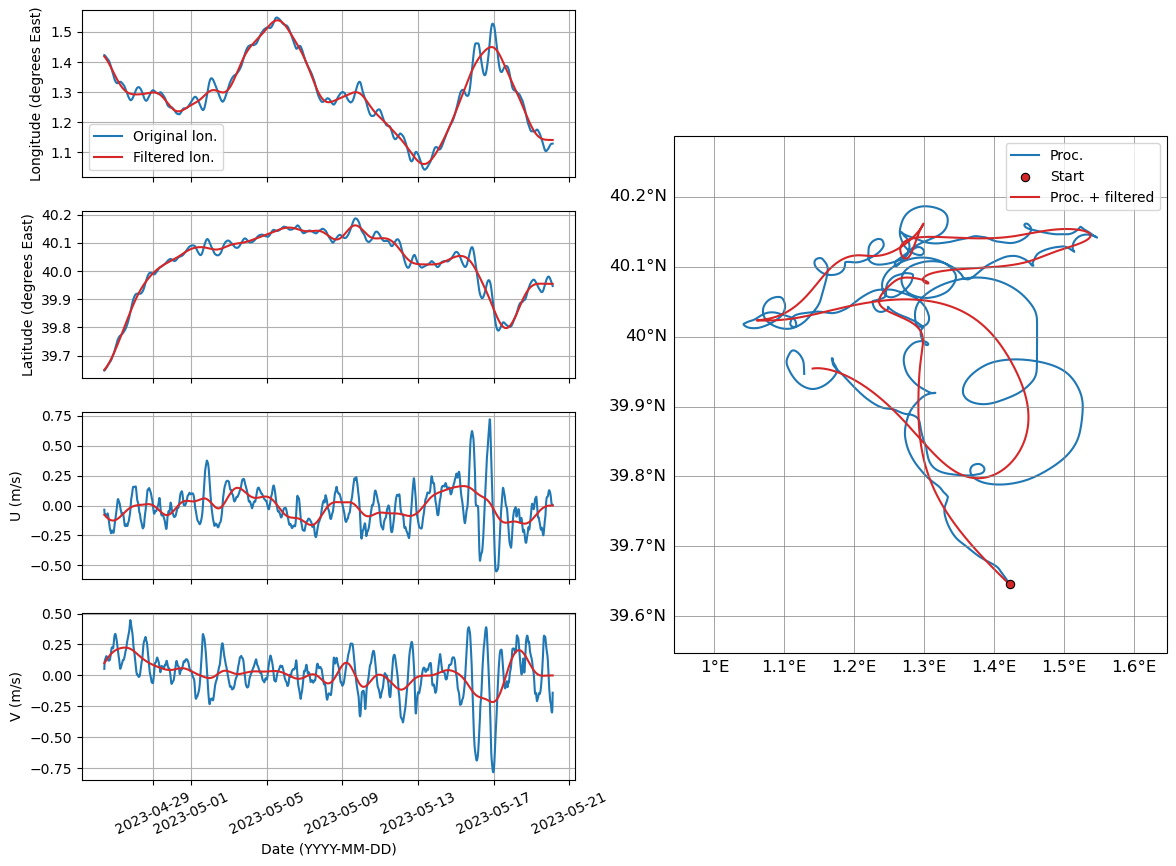

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe001_inertial_osc_filt_v2.nc
2
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe007-ime_carthe002.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe002_inertial_osc_filt_v2.jpg


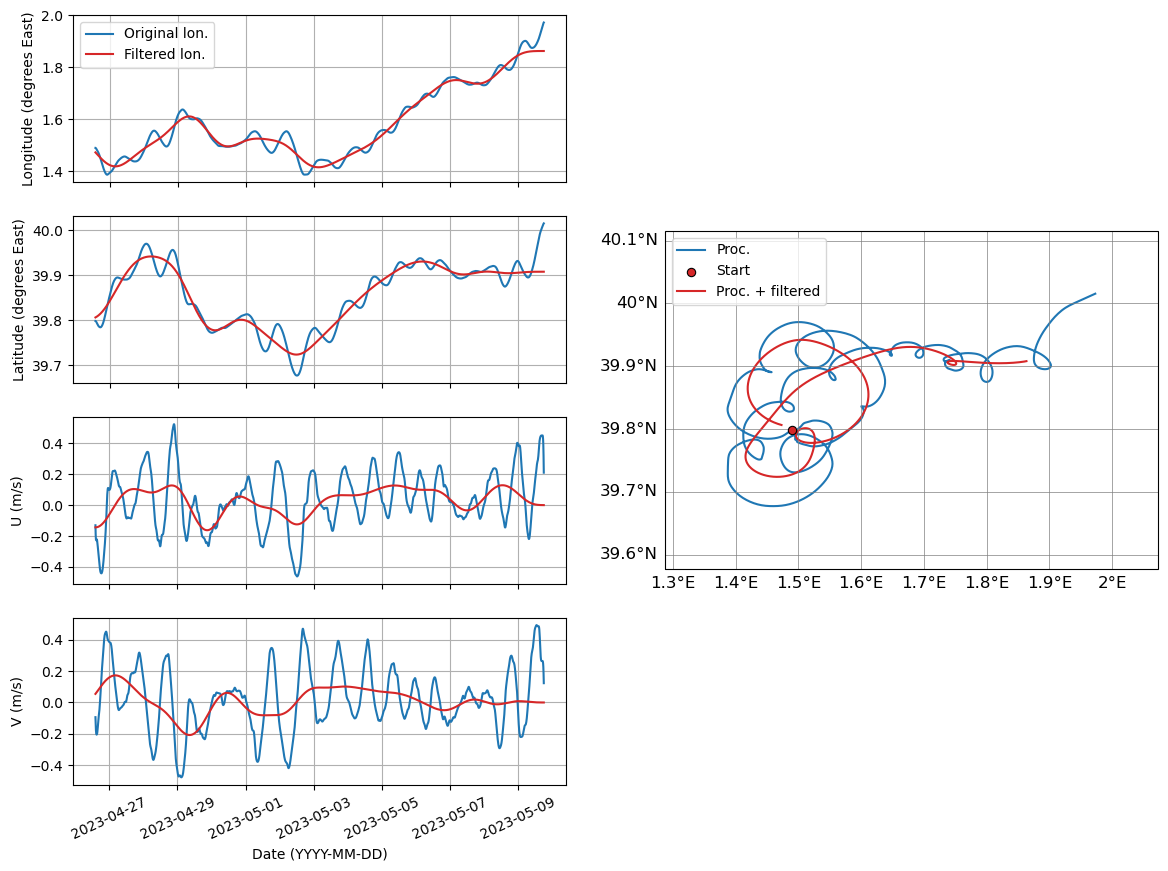

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe002_inertial_osc_filt_v2.nc
3
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe008-ime_carthe003.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe003_inertial_osc_filt_v2.jpg


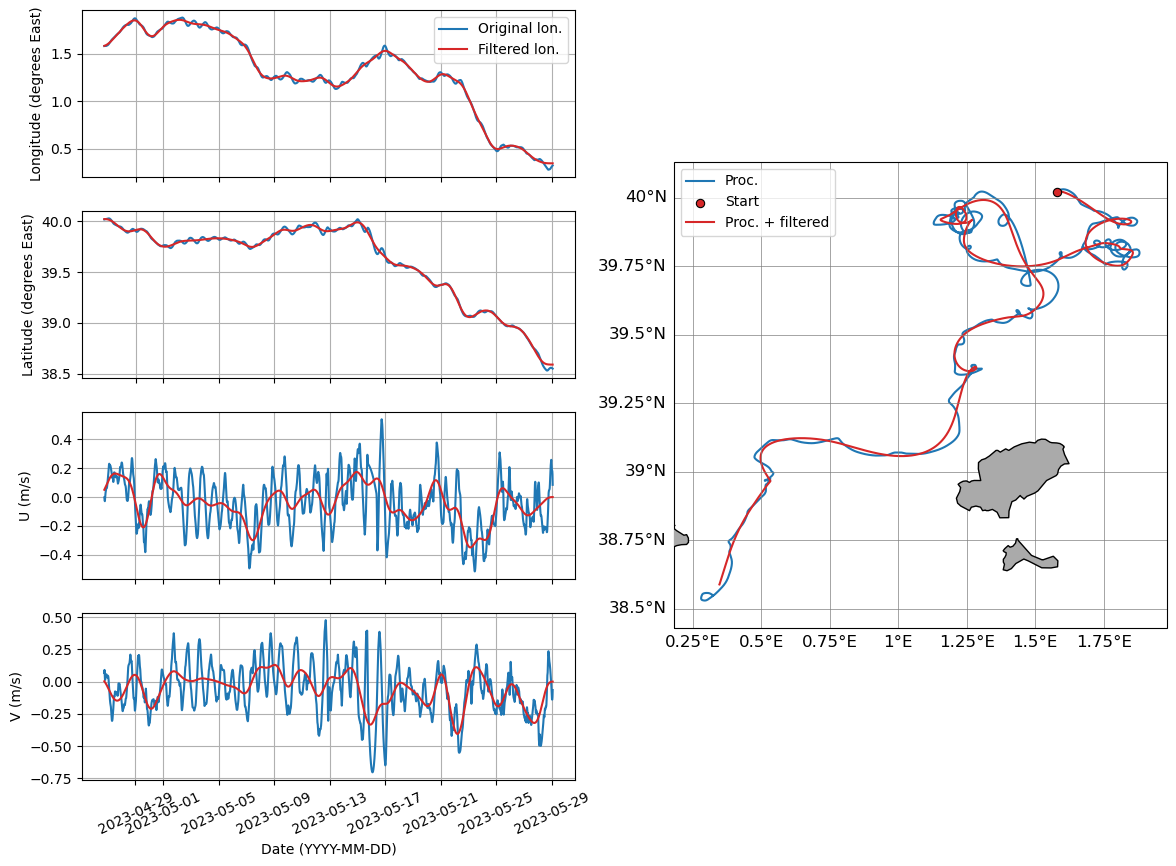

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe003_inertial_osc_filt_v2.nc
4
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe009-ime_carthe004.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe004_inertial_osc_filt_v2.jpg


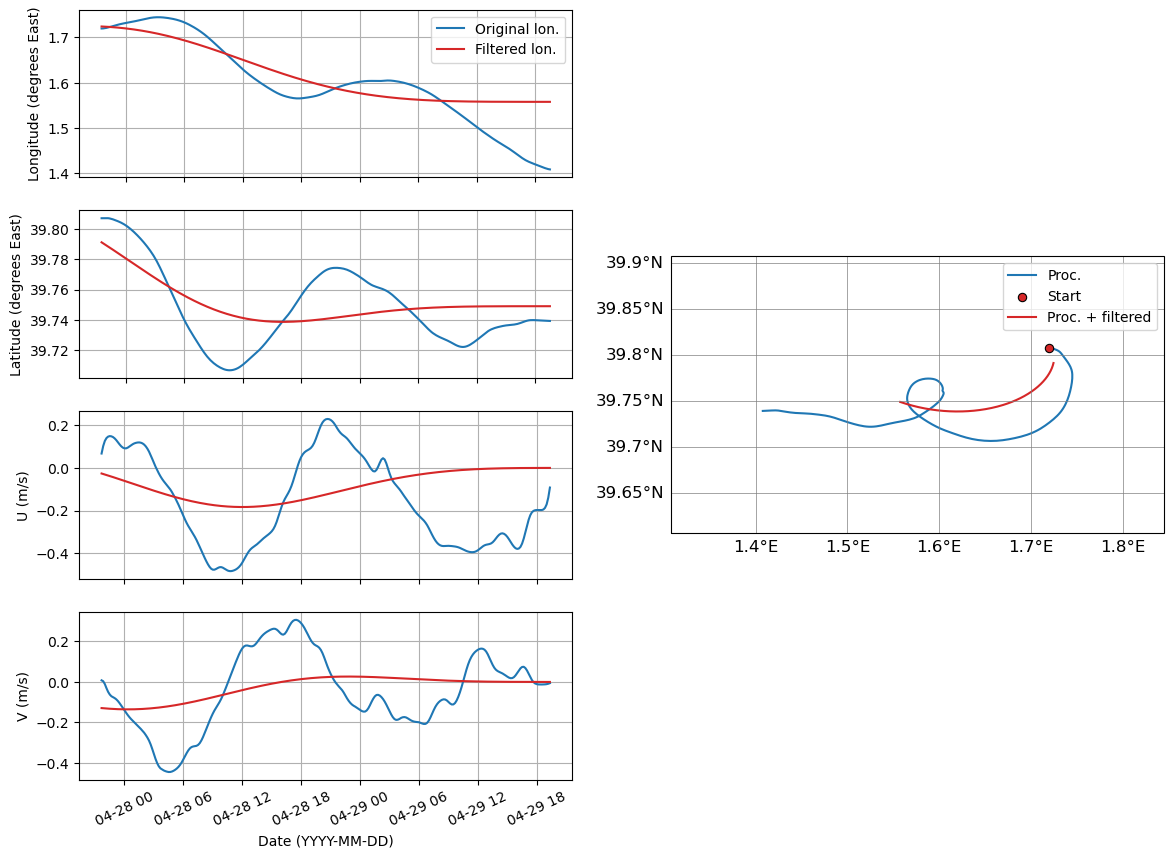

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe004_inertial_osc_filt_v2.nc
5
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe010-ime_carthe005.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe005_inertial_osc_filt_v2.jpg


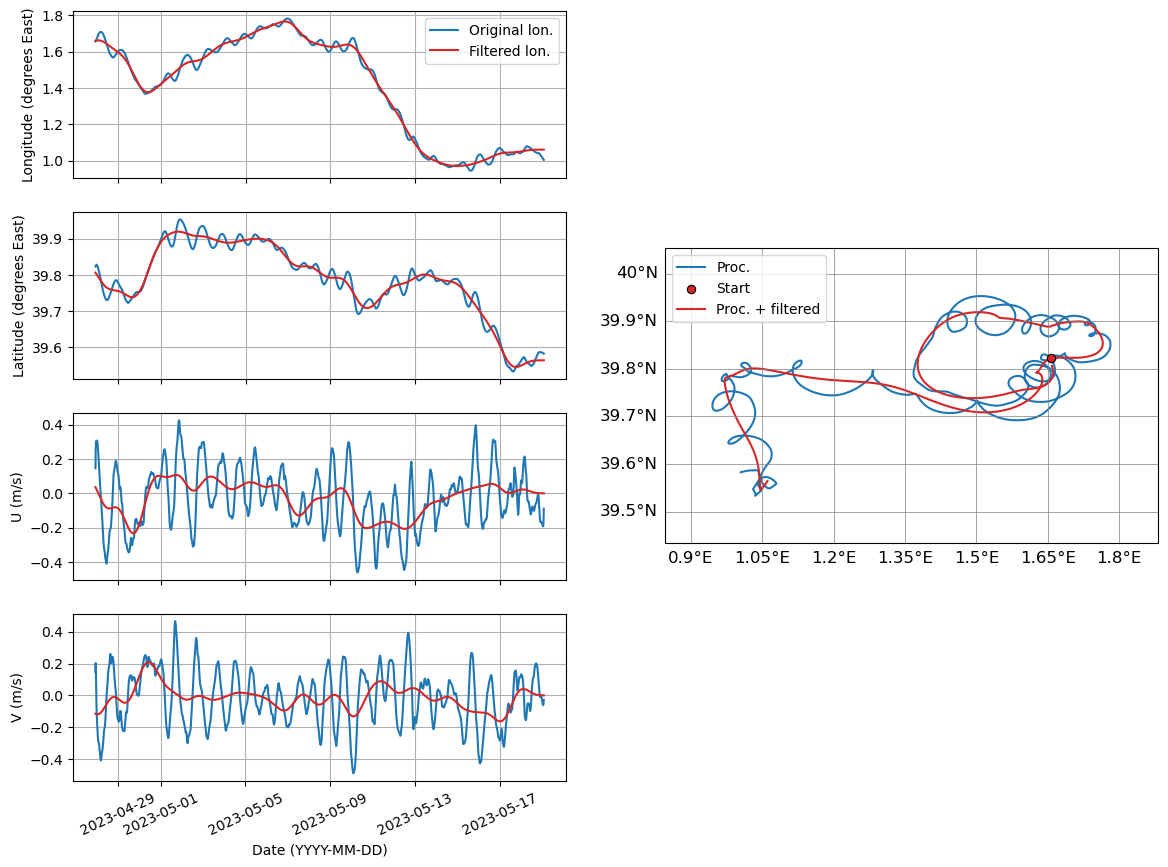

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe005_inertial_osc_filt_v2.nc
6
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe011-ime_carthe006.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe006_inertial_osc_filt_v2.jpg


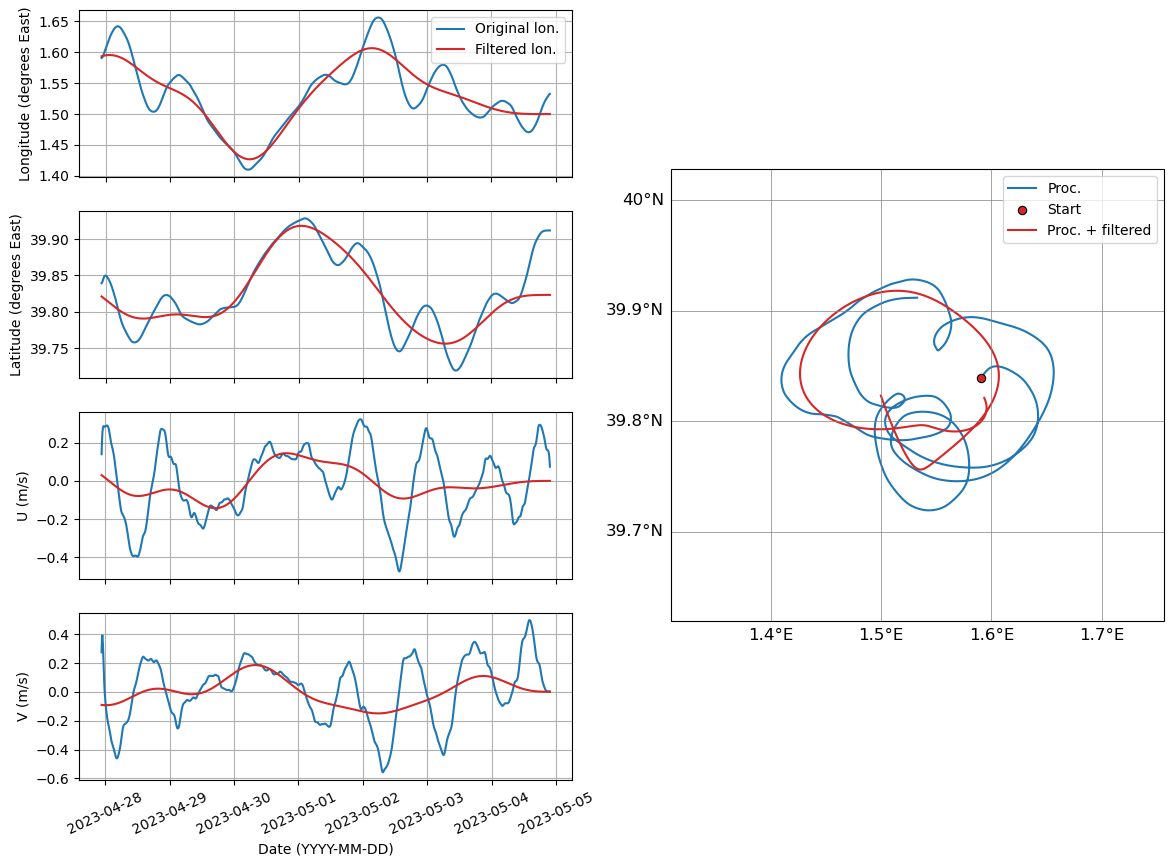

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe006_inertial_osc_filt_v2.nc
7
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe012-ime_carthe007.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe007_inertial_osc_filt_v2.jpg


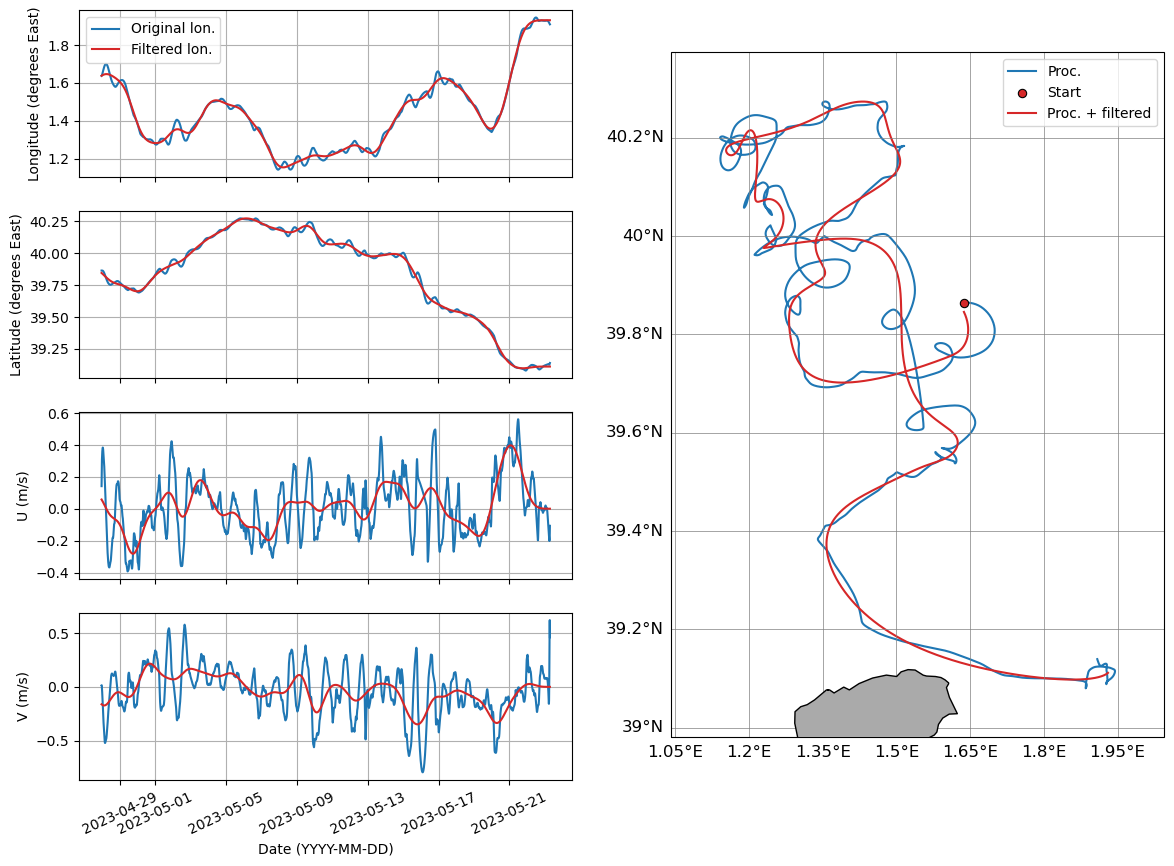

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe007_inertial_osc_filt_v2.nc
8
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe013-ime_carthe008.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe008_inertial_osc_filt_v2.jpg


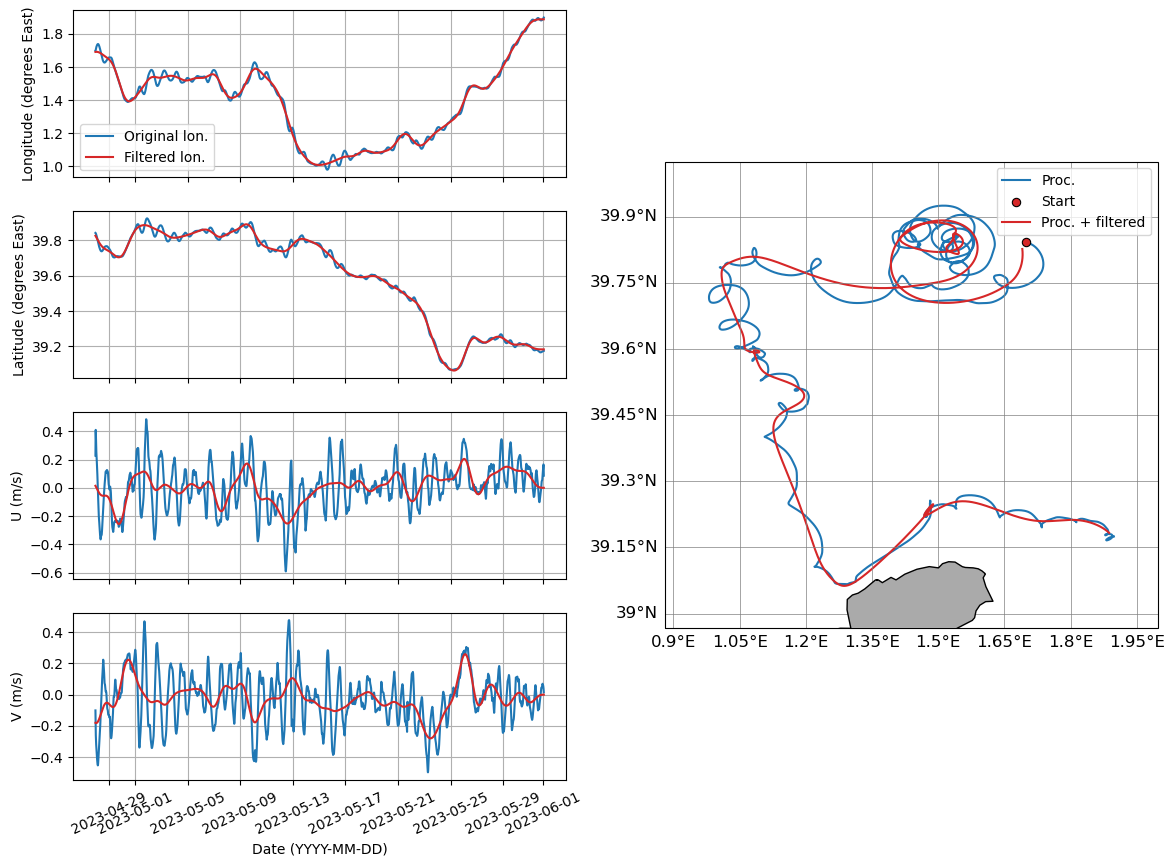

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe008_inertial_osc_filt_v2.nc
9
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe014-ime_carthe009.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe009_inertial_osc_filt_v2.jpg


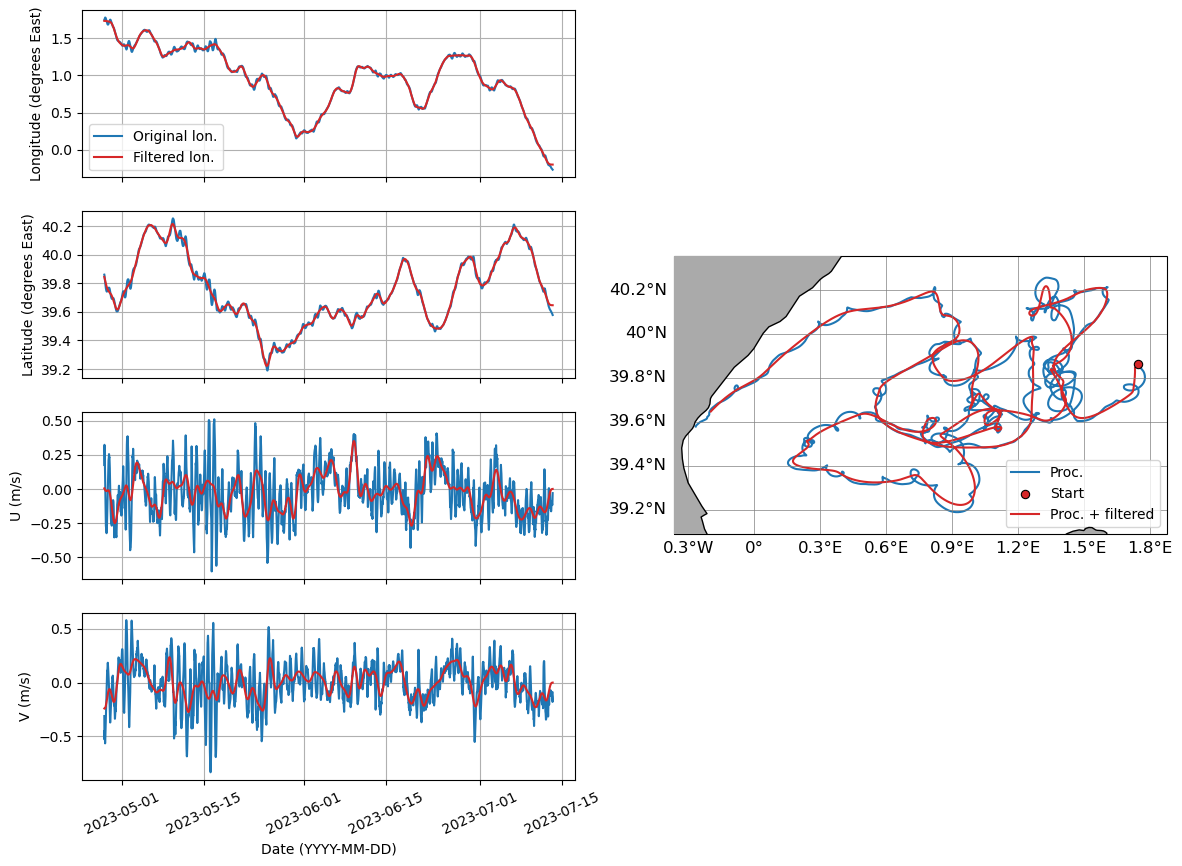

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe009_inertial_osc_filt_v2.nc
10
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe015-ime_carthe010.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe010_inertial_osc_filt_v2.jpg


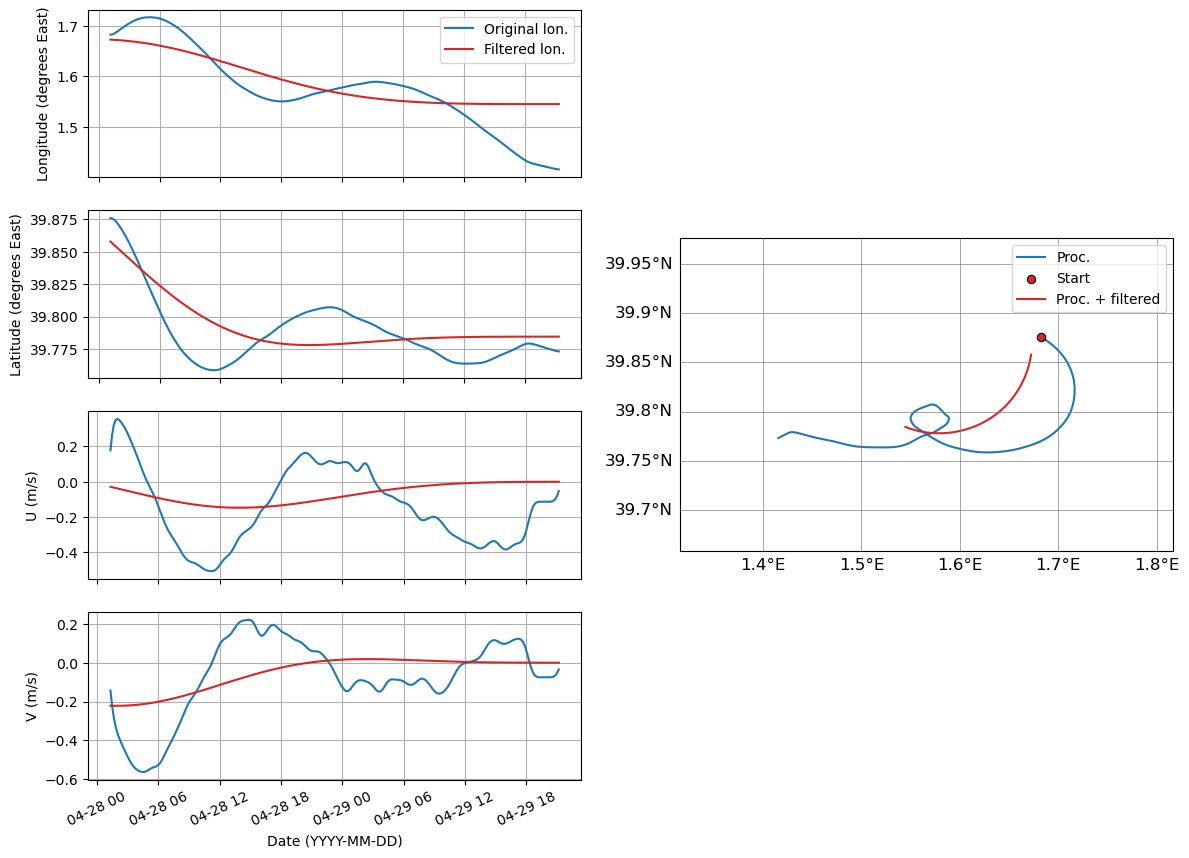

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe010_inertial_osc_filt_v2.nc
11
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe016-ime_carthe011.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe011_inertial_osc_filt_v2.jpg


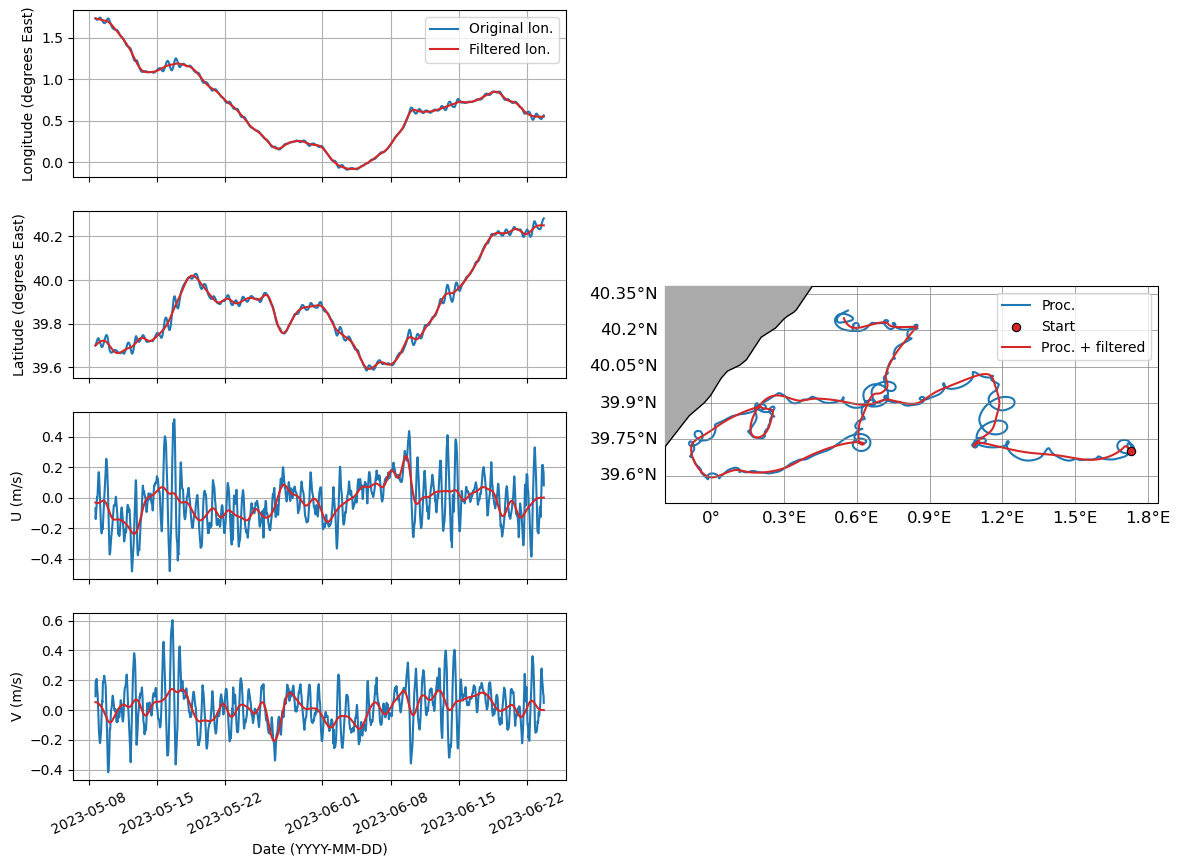

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe011_inertial_osc_filt_v2.nc
12
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe017-ime_carthe012.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe012_inertial_osc_filt_v2.jpg


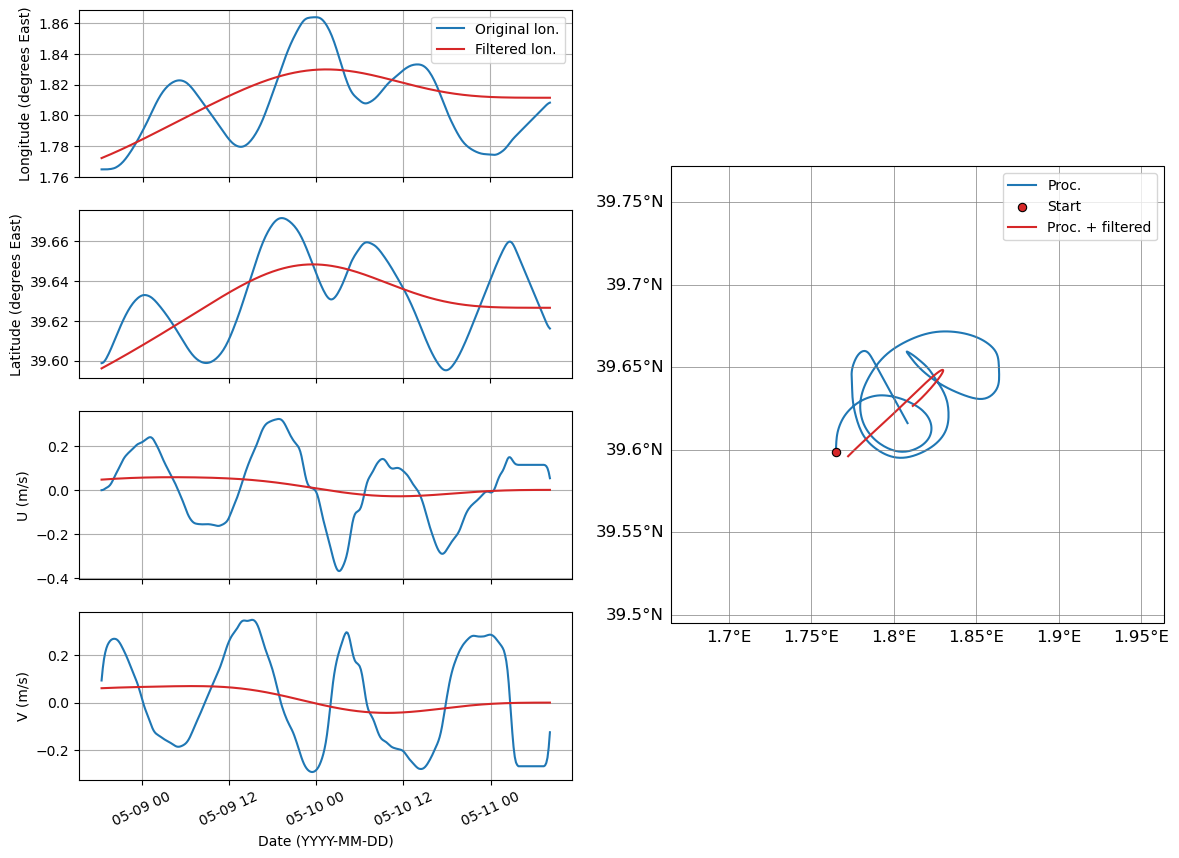

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe012_inertial_osc_filt_v2.nc
13
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe018-ime_carthe013.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe013_inertial_osc_filt_v2.jpg


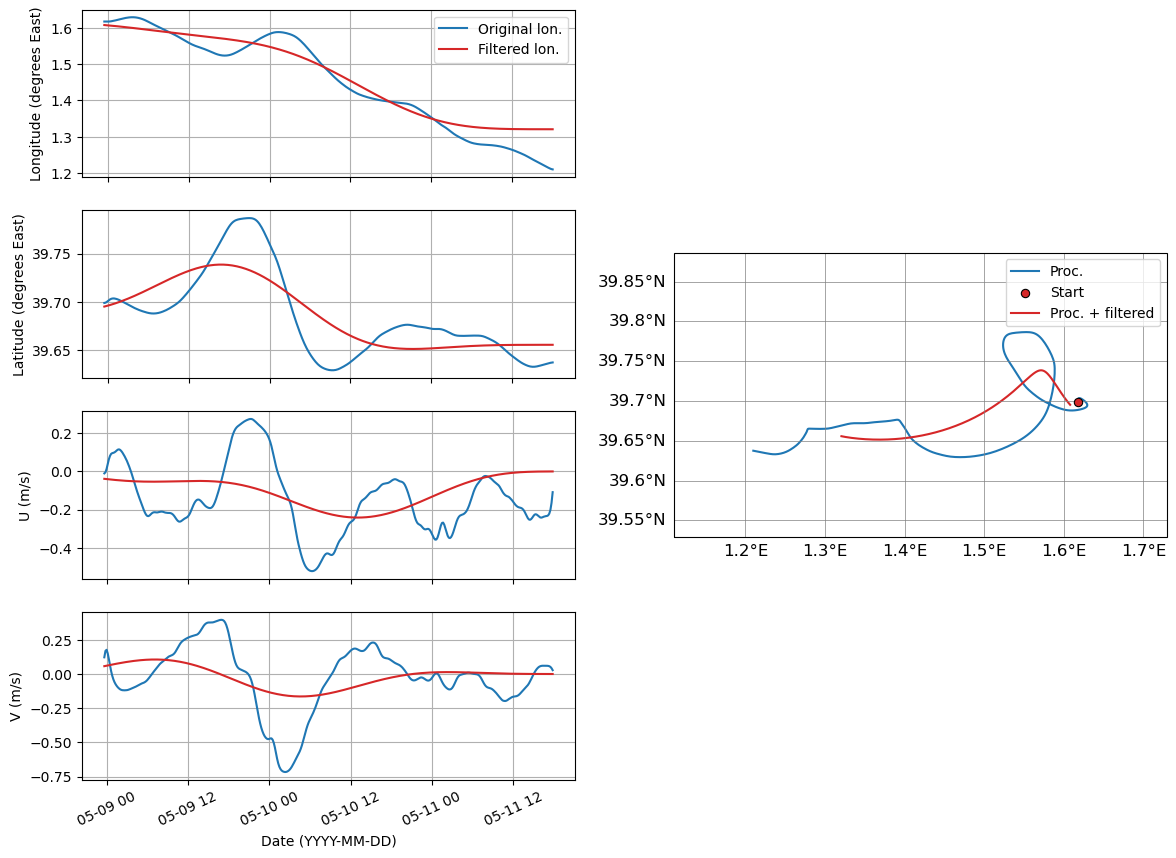

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe013_inertial_osc_filt_v2.nc
14
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe019-ime_carthe014.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe014_inertial_osc_filt_v2.jpg


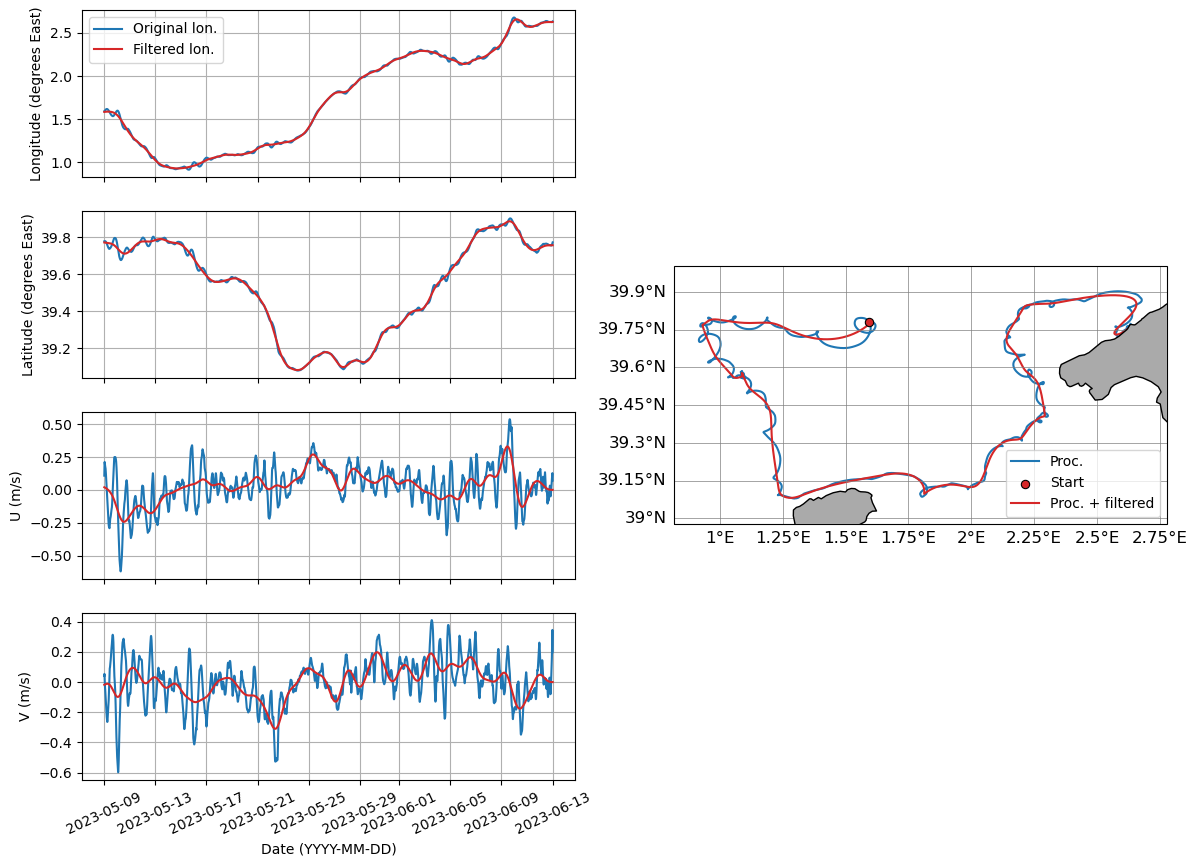

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe014_inertial_osc_filt_v2.nc
15
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe020-ime_carthe015.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe015_inertial_osc_filt_v2.jpg


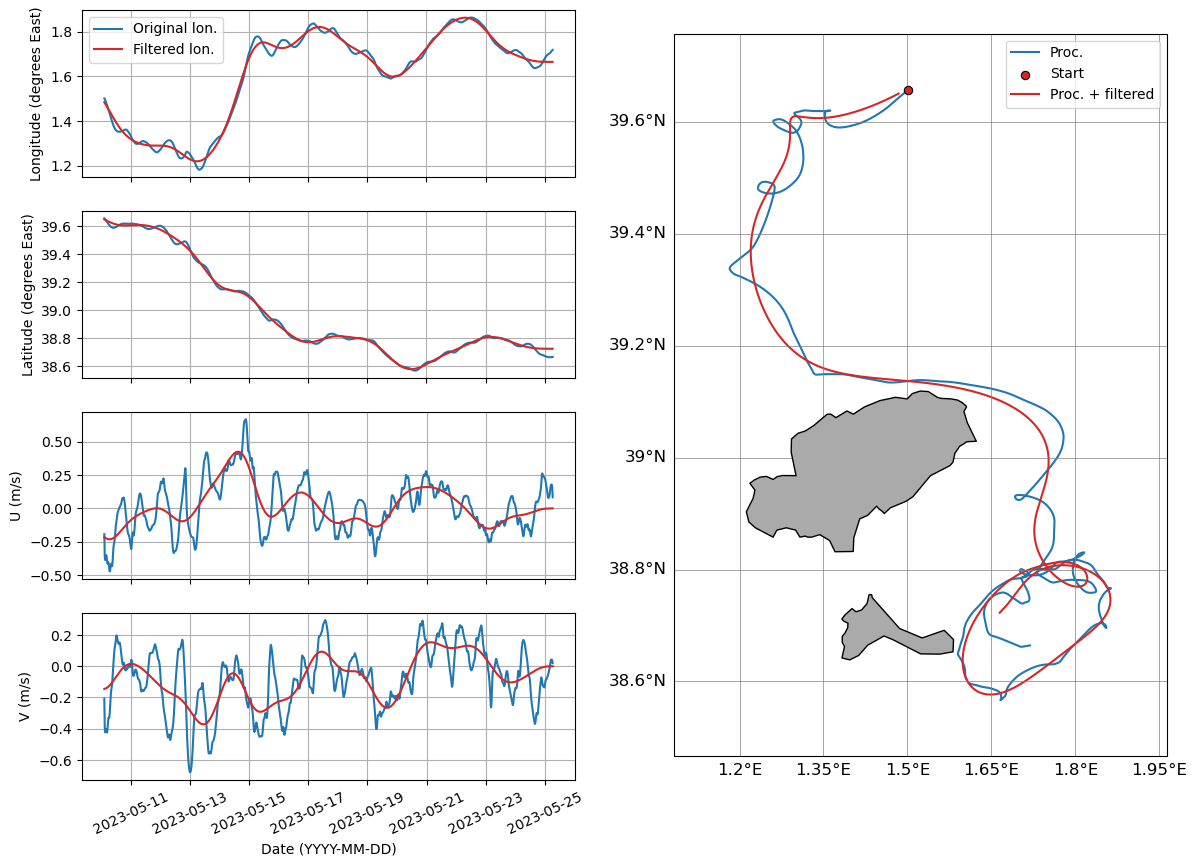

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe015_inertial_osc_filt_v2.nc
16
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe021-ime_carthe016.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe016_inertial_osc_filt_v2.jpg


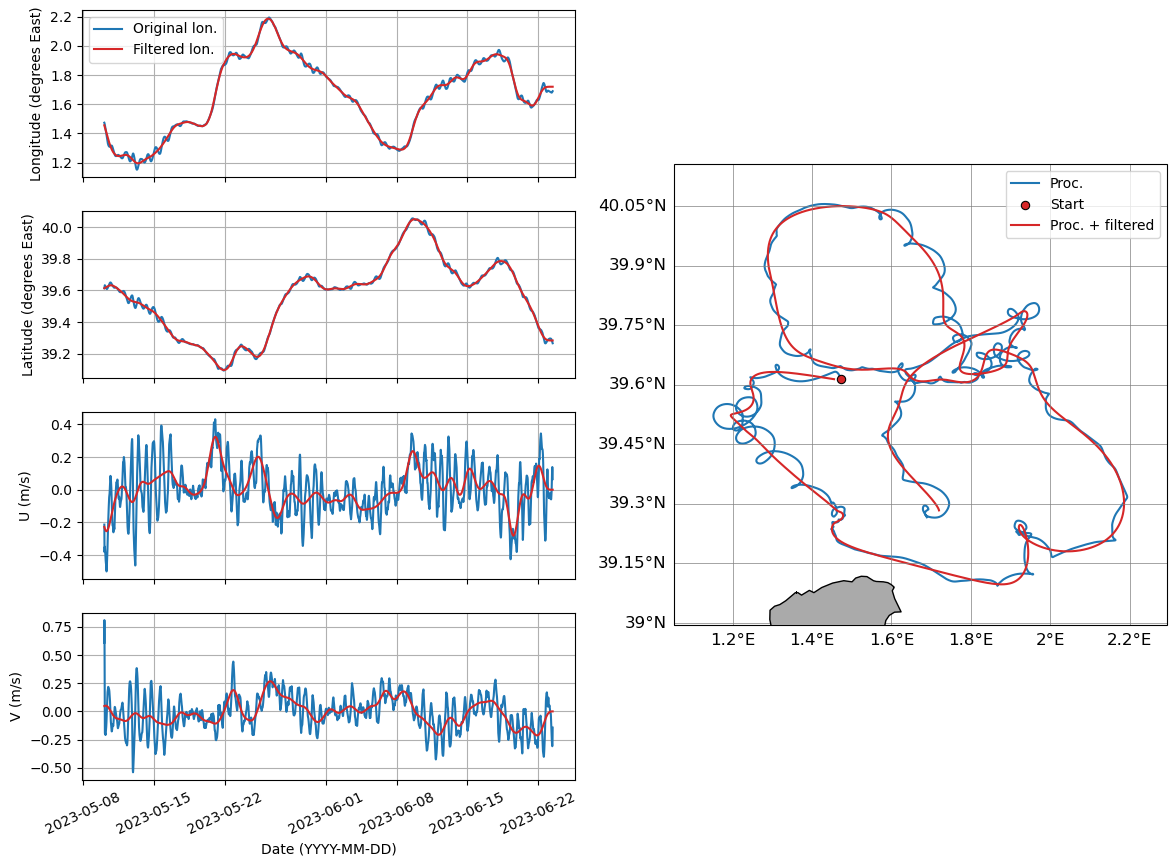

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe016_inertial_osc_filt_v2.nc
17
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe022-ime_carthe017.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe017_inertial_osc_filt_v2.jpg


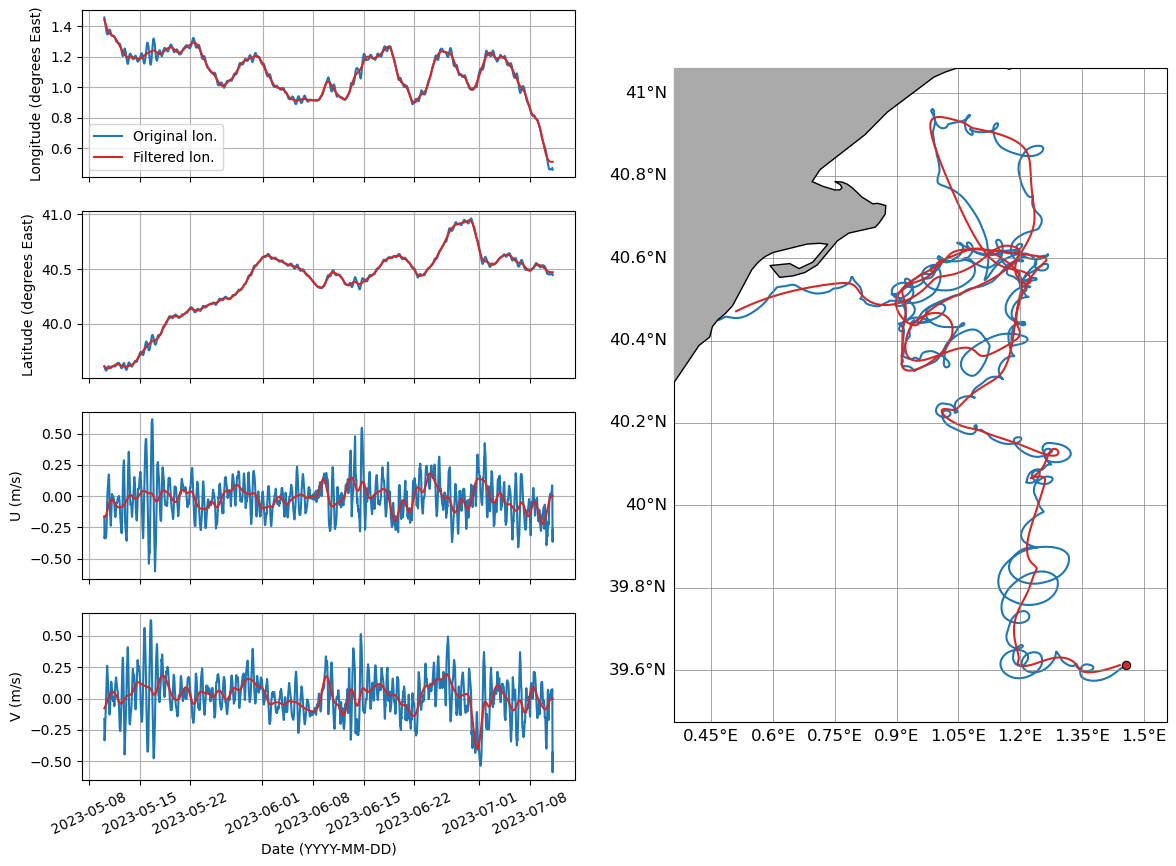

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe017_inertial_osc_filt_v2.nc
18
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe023-ime_carthe018.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe018_inertial_osc_filt_v2.jpg


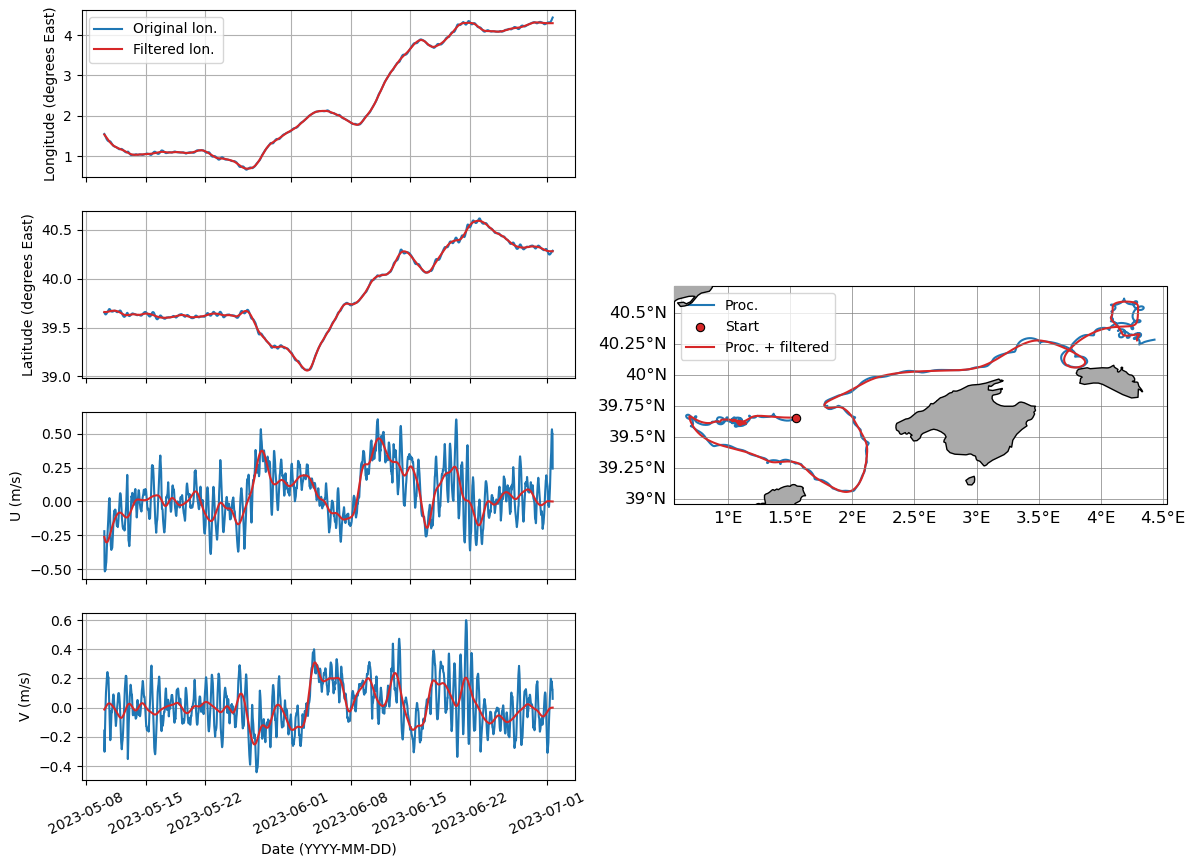

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe018_inertial_osc_filt_v2.nc
19
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe024-ime_carthe019.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe019_inertial_osc_filt_v2.jpg


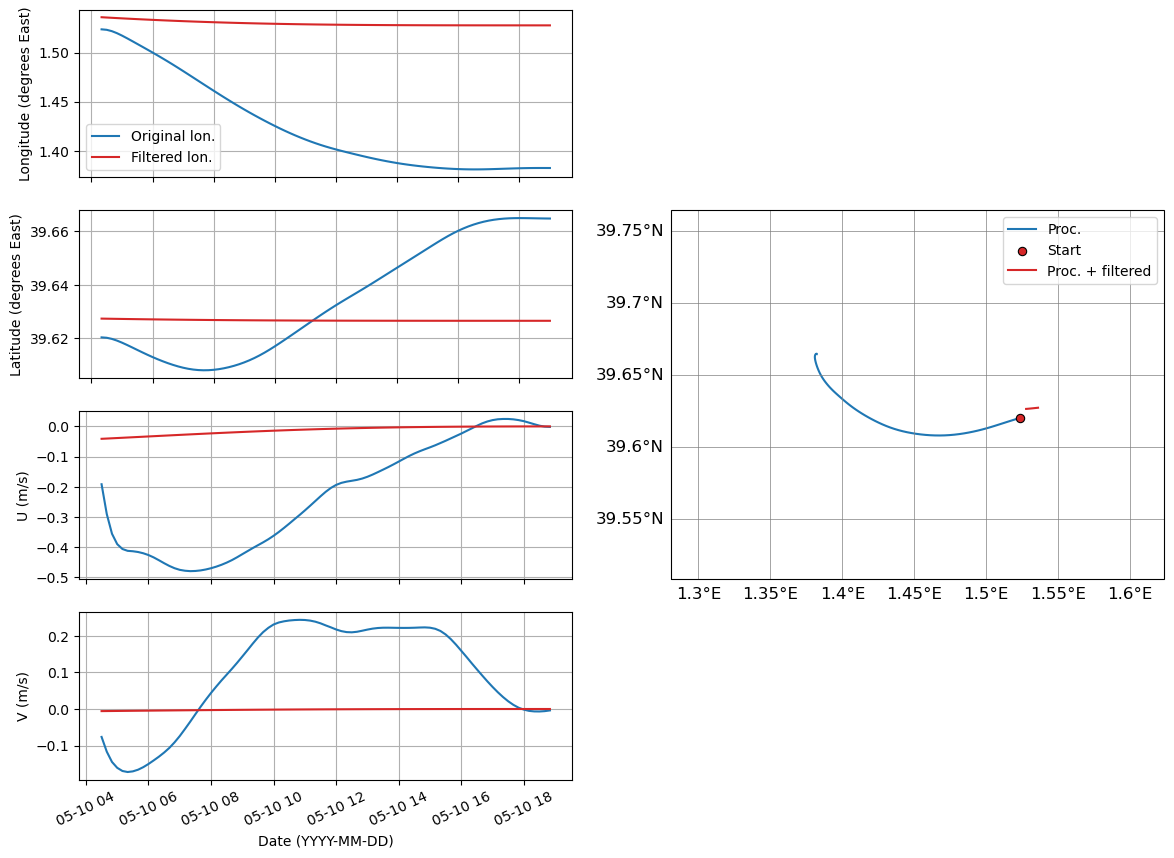

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe019_inertial_osc_filt_v2.nc
20
Input file: ./../../../../../../data/drifters/L1_IMEDEA/drifter_carthe025-ime_carthe020.nc
Fig. saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Figures/Drifters/IOs/drifter-carthe020_inertial_osc_filt_v2.jpg


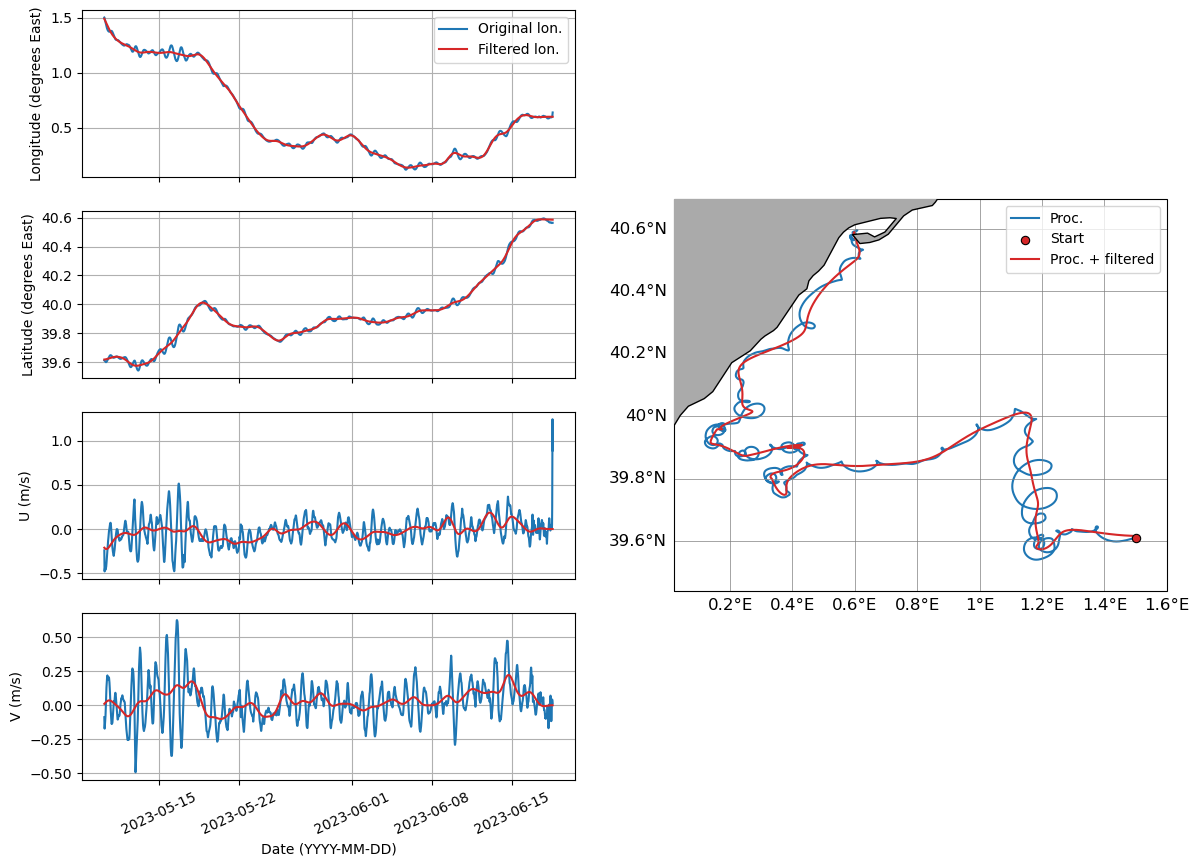

Output file saved at: /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/drifter-carthe020_inertial_osc_filt_v2.nc


In [10]:
for ndrifter in ndrifters:
    print(ndrifter)
    drifter_num = str(ndrifter).zfill(3)
    drifter_num2 = str(ndrifter+5).zfill(3)
    outname = 'drifter_carthe' + drifter_num2 + '-ime_carthe' + drifter_num
    infile = filedir + outname + ".nc"
    print("Input file: " + infile)
    ures, vres = filt_ios_butter(infile, drifter_type="C",
                          outdir=outdir_root + 'Data/in_situ/analyses/drifters/CARTHE/', 
                          plot_output="yes",
                          savefigdir=outdir_root + 'Figures/Drifters/IOs/')
    plt.show()

In [11]:
# !rm  /Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/CARTHE/*_CU.nc
